# SincNet for DataSEC environmental sound classification

This notebook trains a SincNet-based waveform classifier from scratch. It covers dataset validation, exploratory data analysis, a reproducible recording-level split, training, model selection, test evaluation, filter interpretation, and inference. The convolutional head is adapted for environmental sounds, so this is not an exact reproduction of the original speaker recognition experiment.

In [4]:
import os, re, json, math, random, time, hashlib, zipfile, platform, shutil
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
from scipy.signal import resample_poly, spectrogram
from tqdm.auto import tqdm
from IPython.display import display, Audio, Markdown
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print({"python": platform.python_version(), "torch": torch.__version__, "cuda": torch.cuda.is_available()})


{'python': '3.12.13', 'torch': '2.10.0+cu128', 'cuda': True}


## 1. Experiment configuration
The default uses 16 kHz audio and 2-second crops to keep raw-waveform training practical. This removes frequencies above 8 kHz, which can matter for birds and insects. For a higher-bandwidth experiment, set `SAMPLE_RATE=32000` before running and keep that setting consistent across the comparison.

Training sees a fresh random crop of each recording per epoch. Validation and test average probabilities over five evenly spaced crops, giving one prediction per recording. These are sampled views, not exhaustive coverage of long files. Validation macro-F1 selects the checkpoint. Test recordings are evaluated only after model selection.

Set `SHARED_SPLIT` to a previously exported manifest to reuse it exactly. Optional `GROUP_CSV` has columns `relative_path,group_id` and should identify recordings from the same original source or session. If source metadata is unavailable, the default split cannot guarantee independence of acoustically related recordings.


In [5]:
DATA_ROOT = None
SHARED_SPLIT = None
GROUP_CSV = None
OUTPUT = Path("/kaggle/working/sincnet_datasec")
SEED = 42
SAMPLE_RATE = 16000
CROP_SECONDS = 2.0
EVAL_CROPS = 5
BATCH_SIZE = 16
EPOCHS = 40
PATIENCE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
EXPECTED_CLASSES = 22
CLASS_OVERRIDES = {}
OUTPUT.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_SAMPLES = int(SAMPLE_RATE * CROP_SECONDS)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("CPU mode works, but full training will be slow. Enable a Kaggle GPU.")


Device: cuda


In [6]:
import hashlib
import urllib.request
from pathlib import Path

download_dir = Path("/kaggle/working/datasec_download")
download_dir.mkdir(parents=True, exist_ok=True)

archive = download_dir / "DATASEC.zip"
url = "https://zenodo.org/records/17033970/files/DATASEC.zip?download=1"
expected_md5 = "29fa9b8cc84cfa69aa4e5e674e780383"

if not archive.exists():
    temporary = archive.with_suffix(".zip.part")
    print("Downloading DataSEC. This may take several minutes.")

    request = urllib.request.Request(url, headers={"User-Agent": "DataSEC-notebook"})
    with urllib.request.urlopen(request, timeout=120) as response:
        with temporary.open("wb") as output:
            while chunk := response.read(8 * 1024 * 1024):
                output.write(chunk)

    temporary.replace(archive)

print("Checking download integrity...")
checksum = hashlib.md5()
with archive.open("rb") as source:
    while chunk := source.read(8 * 1024 * 1024):
        checksum.update(chunk)

if checksum.hexdigest() != expected_md5:
    archive.unlink()
    raise RuntimeError("Download verification failed. Rerun this cell.")

DATA_ROOT = str(download_dir)
print("Dataset ready:", archive)

Checking download integrity...
Dataset ready: /kaggle/working/datasec_download/DATASEC.zip


## 2. Discover files and resolve parent labels
Labels come from class folders, not guessed filename prefixes. The resolver recognizes the 22 parent labels and documented subclasses, including common singular and plural forms. It stops on unknown or conflicting folders instead of silently creating the wrong target classes. For a renamed folder, add its exact name and intended parent label to `CLASS_OVERRIDES`.

ZIP extraction preserves directories and rejects unsafe member paths. If you attach multiple ZIP files without extracted WAVs, specify the dataset directory or extract the intended archive first.


In [7]:
PARENTS = ["Bells", "Birds", "Cat fights and moans", "Chicken coop", "Cicadas and crickets",
 "Crows seagulls and magpies", "Dog barkings and howlings", "Glass breaking", "Horn",
 "Jet aircrafts", "Lawn mower brush cutter and olive shaker", "Music", "Propeller aircrafts",
 "Sirens and alarms", "Thunder fireworks and gunshot", "Train", "Vacuum cleaner fan and hairdryer",
 "Vehicle idling", "Vehicle pass-by", "Voices", "Wind turbine", "Workshop"]
SUBCLASSES = {
 "Cicadas and crickets": ["Cicadas", "Crickets"],
 "Crows seagulls and magpies": ["Crows", "Seagulls", "Magpies"],
 "Lawn mower brush cutter and olive shaker": ["Lawn mower", "Brush cutter", "Olive shaker"],
 "Propeller aircrafts": ["Airplanes", "Helicopters", "Propeller airplanes"],
 "Sirens and alarms": ["Sirens", "Alarms"],
 "Thunder fireworks and gunshot": ["Thunder", "Fireworks", "Gunshot", "Gunshots"],
 "Vacuum cleaner fan and hairdryer": ["Vacuum cleaner", "Fan", "Hairdryer"],
 "Vehicle idling": ["Car-truck idling", "Car idling", "Truck idling", "Motorbike idling"],
 "Vehicle pass-by": ["Car pass-by", "Motorbike pass-by", "Truck pass-by"],
 "Workshop": ["Air compressor", "Drill", "Grinder", "Jackhammer", "Saw"]}
def norm(s):
    words = re.findall(r"[a-z]+", s.lower())
    return "".join(w[:-1] if w.endswith("s") else w for w in words if w != "and")
aliases = {norm(p): p for p in PARENTS}
for parent, children in SUBCLASSES.items():
    aliases.update({norm(c): parent for c in children})
assert set(CLASS_OVERRIDES.values()) <= set(PARENTS)
aliases.update({norm(k): v for k, v in CLASS_OVERRIDES.items()})
root = Path(DATA_ROOT) if DATA_ROOT else Path("/kaggle/input")
assert root.exists(), f"Dataset path does not exist: {root}"
def wav_files(folder):
    return sorted(p for p in folder.rglob("*") if p.suffix.lower() == ".wav" and not p.name.startswith("._"))
files = wav_files(root)
if not files:
    archives = sorted(root.rglob("*.zip"))
    assert len(archives) == 1, "Attach DataSEC WAV files or one DataSEC ZIP; set DATA_ROOT if needed."
    extract_root = OUTPUT / "extracted"
    extract_root.mkdir(exist_ok=True)
    with zipfile.ZipFile(archives[0]) as z:
        for item in z.infolist():
            target = (extract_root / item.filename).resolve()
            assert target.is_relative_to(extract_root.resolve()), "Unsafe ZIP member"
        z.extractall(extract_root)
    root = extract_root
    files = wav_files(root)
assert files, "No WAV files found."
root = Path(os.path.commonpath([str(p.parent) for p in files]))
records, unresolved = [], []
for p in files:
    rel = p.relative_to(root)
    candidates = {aliases[norm(part)] for part in rel.parts[:-1] if norm(part) in aliases}
    if len(candidates) != 1:
        unresolved.append(str(rel))
    else:
        records.append({"path": str(p), "relative_path": rel.as_posix(),
                        "label": candidates.pop(), "folder": p.parent.name})
assert not unresolved, f"Unknown or conflicting class folders. Set DATA_ROOT or CLASS_OVERRIDES. Examples: {unresolved[:15]}"
df = pd.DataFrame(records)
assert df.label.nunique() == EXPECTED_CLASSES, f"Expected {EXPECTED_CLASSES} classes, found {df.label.nunique()}: {sorted(df.label.unique())}"
print(f"Found {len(df):,} recordings in {df.label.nunique()} parent classes.")
if len(df) != 4292:
    print("File count differs from the synopsis. Check the dataset release and report the actual count.")
display(df.groupby(["label", "folder"]).size().rename("recordings").to_frame())


Found 5,048 recordings in 22 parent classes.
File count differs from the synopsis. Check the dataset release and report the actual count.


recordings
label                                    folder                               
Bells                                    Bells                              67
Birds                                    Birds                              69
Cat fights and moans                     Cat fights and moans               50
Chicken coop                             Chicken coop                       58
Cicadas and crickets                     Cicadas                            54
                                         Crickets                           20
Crows seagulls and magpies               Crows                              50
                                         Magpies                            21
                                         Seagulls                           35
Dog barkings and howlings                Dog barkings and howlings          70
Glass breaking                           Glass breaking                    109
Horn                                     Horn                               57
Jet aircrafts                            Jet aircrafts                     103
Lawn mower brush cutter and olive shaker Brush cutter                       86
                                         Lawn mower                         21
                                         Olive shaker                       20
Music                                    Music                            1001
Propeller aircrafts                      Airplanes                          50
                                         Helicopters                        58
Sirens and alarms                        Alarms                             37
                                         Sirens                             68
Thunder fireworks and gunshot            Fireworks                          68
                                         Gunshot                           141
                                         Thunder                            26
Train                                    Train                              67
Vacuum cleaner fan and hairdryer         fan                                32
                                         hairdryer                          32
                                         vacuum cleaner                     31
Vehicle idling                           car truck idling                   81
                                         motorbike idling                   31
Vehicle pass-by                          car pass-by                       110
                                         motorbike pass-by                  57
                                         truck pass-by                      50
Voices                                   Voices                           1900
Wind turbine                             Wind turbine                      100
Workshop                                 air compressor                     30
                                         drill                              45
                                         grinder                            38
                                         jackhammer                         63
                                         saw                                42

## 3. Audio integrity and dataset inventory
Every recording is decoded once to check duration, sample rate, channel count, nonfinite samples, silence, amplitude, clipping, and exact decoded-audio duplicates. Hashing decoded samples detects identical audio even when WAV metadata differs. Conflicting labels for identical audio stop the run. Repeated audio with the same label is reduced to one recording before splitting.

Clipping is estimated as the fraction of samples with absolute amplitude at least 0.999. Silence uses an absolute 0.001 threshold and is a descriptive indicator, not a calibrated acoustic measurement. Invalid files are logged and excluded explicitly. Near-duplicates and shared recording sessions require source metadata and are not detected by an exact hash.


In [8]:
def inspect_audio(row):
    try:
        x, sr = sf.read(row["path"], dtype="float32", always_2d=True)
        if len(x) == 0 or not np.isfinite(x).all():
            raise ValueError("Empty or nonfinite audio")
        peak = float(np.abs(x).max())
        if peak < 1e-8:
            raise ValueError("Silent audio")
        h = hashlib.sha256()
        h.update(str((sr, x.shape)).encode())
        h.update(x.tobytes())
        return {**row, "sample_rate": sr, "channels": x.shape[1], "duration": len(x)/sr,
                "peak": peak, "rms": float(np.sqrt(np.mean(x.astype(np.float64)**2))),
                "silence_fraction": float(np.mean(np.abs(x) < 0.001)),
                "clip_fraction": float(np.mean(np.abs(x) >= 0.999)), "audio_hash": h.hexdigest(), "error": ""}
    except Exception as e:
        return {**row, "error": str(e)}
with ThreadPoolExecutor(max_workers=4) as pool:
    inventory = pd.DataFrame(list(tqdm(pool.map(inspect_audio, df.to_dict("records")), total=len(df))))
inventory.to_csv(OUTPUT / "audio_inventory.csv", index=False)
invalid = inventory[inventory.error != ""]
invalid.to_csv(OUTPUT / "invalid_audio.csv", index=False)
df = inventory[inventory.error == ""].copy()
assert len(df), "No valid recordings."
conflicts = df.groupby("audio_hash").label.nunique()
assert conflicts.max() == 1, "Identical audio has conflicting labels. Review audio_inventory.csv."
duplicates = df[df.duplicated("audio_hash", keep="first")]
duplicates.to_csv(OUTPUT / "duplicate_audio.csv", index=False)
df = df.drop_duplicates("audio_hash").reset_index(drop=True)
assert df.label.nunique() == EXPECTED_CLASSES
print(f"Excluded {len(invalid)} invalid files and {len(duplicates)} exact duplicates.")
display(pd.Series({"usable_recordings": len(df), "classes": df.label.nunique(),
                   "hours": df.duration.sum()/3600, "median_seconds": df.duration.median(),
                   "shorter_than_crop": int((df.duration < CROP_SECONDS).sum())}).to_frame("value"))
display(df.groupby("label").agg(recordings=("path", "size"), total_minutes=("duration", lambda s: s.sum()/60),
                               median_seconds=("duration", "median")).round(2))


  0%|          | 0/5048 [00:00<?, ?it/s]

Excluded 0 invalid files and 16 exact duplicates.


,value
usable_recordings,5032.000000
classes,22.000000
hours,23.583999
median_seconds,8.659320
shorter_than_crop,963.000000


,recordings,total_minutes,median_seconds
label,,,
Bells,67,31.93,29.64
Birds,69,15.13,5.00
Cat fights and moans,50,19.51,19.97
Chicken coop,58,11.56,11.30
Cicadas and crickets,74,28.20,18.20
Crows seagulls and magpies,105,44.79,22.94
Dog barkings and howlings,70,11.21,7.56
Glass breaking,108,66.41,60.52
Horn,57,4.69,1.88


## 4. Exploratory data analysis
The first charts describe dataset composition and recording quality. Class counts reveal imbalance, while total duration reveals whether common classes also contribute more audio. The model samples one crop per recording per epoch, so long files do not automatically receive more training weight.

These inventory plots are descriptive. Detailed signal examples below use only training recordings. Avoid using test errors to choose preprocessing or tune the model.


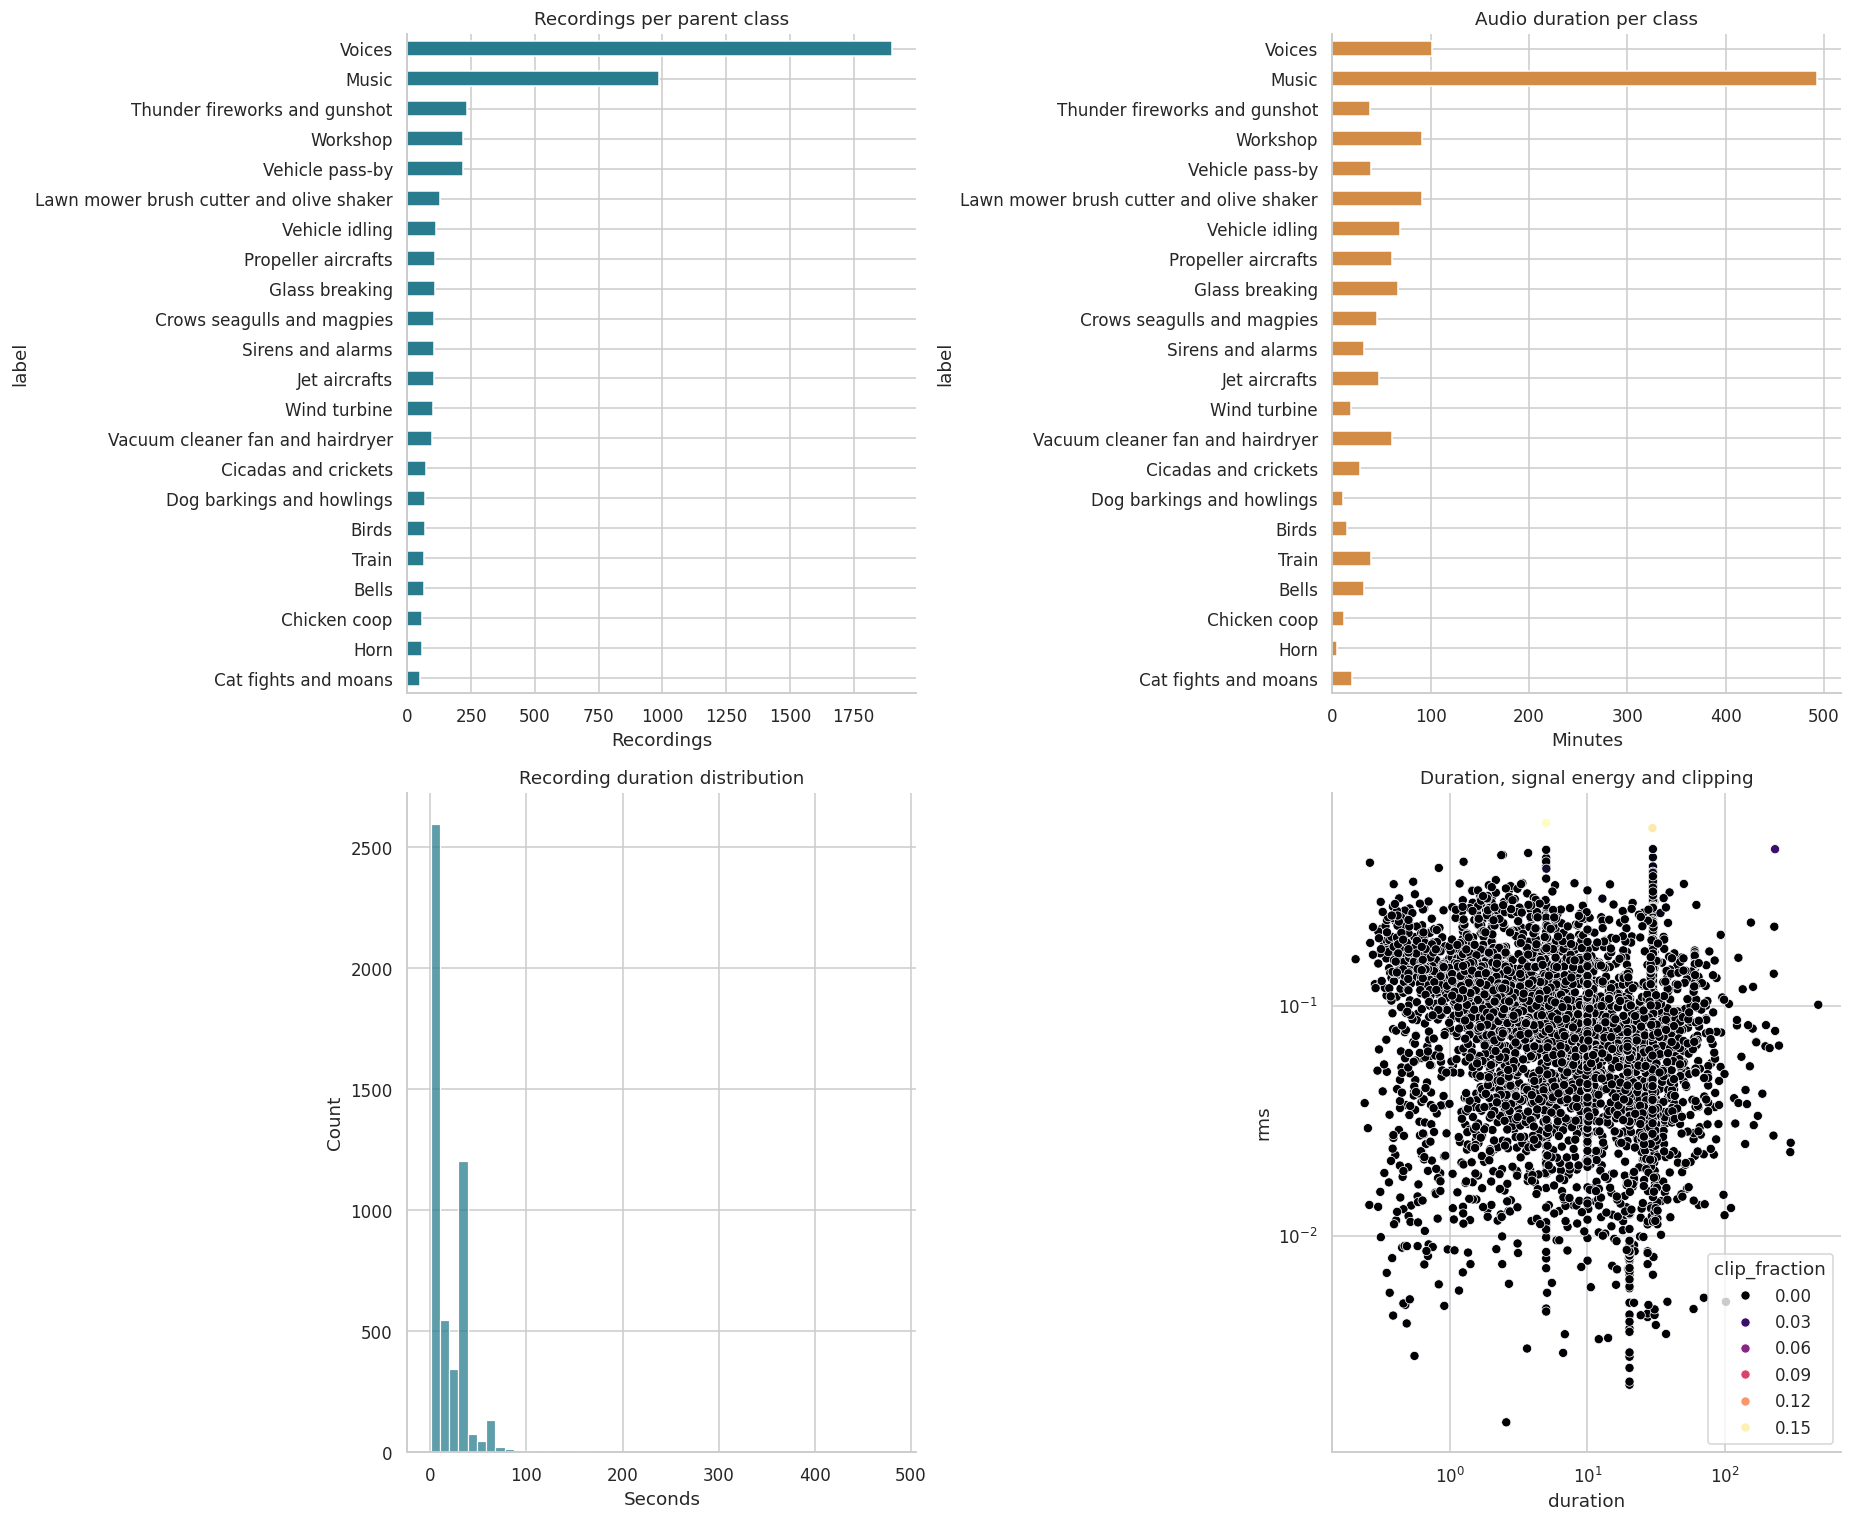

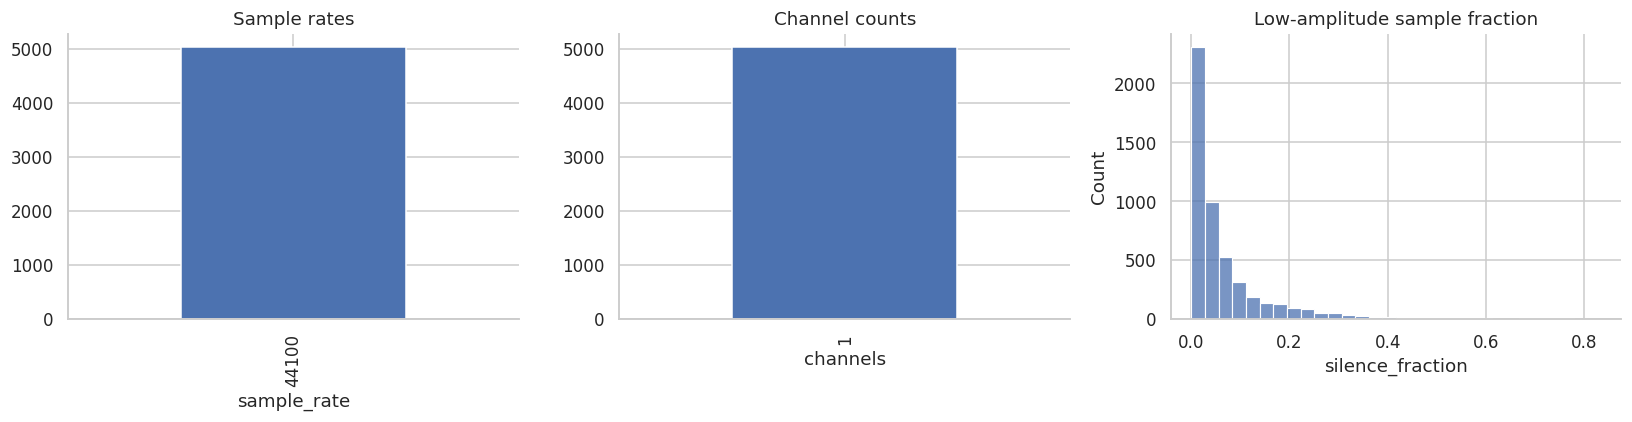

Largest/smallest class ratio: 38.00
Files with >1% near-clipped samples: 5


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(17, 14))
counts = df.label.value_counts().sort_values()
counts.plot.barh(ax=axes[0,0], color="#287c8e", title="Recordings per parent class")
axes[0,0].set_xlabel("Recordings")
(df.groupby("label").duration.sum().reindex(counts.index)/60).plot.barh(ax=axes[0,1], color="#d28c45", title="Audio duration per class")
axes[0,1].set_xlabel("Minutes")
sns.histplot(df.duration, bins=50, ax=axes[1,0], color="#287c8e")
axes[1,0].set(title="Recording duration distribution", xlabel="Seconds")
sns.scatterplot(data=df, x="duration", y="rms", hue="clip_fraction", ax=axes[1,1], palette="magma", legend="brief")
axes[1,1].set(title="Duration, signal energy and clipping", yscale="log", xscale="log")
plt.tight_layout()
plt.savefig(OUTPUT / "eda_overview.png", bbox_inches="tight")
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15,4))
df.sample_rate.value_counts().sort_index().plot.bar(ax=axes[0], title="Sample rates")
df.channels.value_counts().sort_index().plot.bar(ax=axes[1], title="Channel counts")
sns.histplot(df.silence_fraction, bins=30, ax=axes[2])
axes[2].set_title("Low-amplitude sample fraction")
plt.tight_layout(); plt.show()
print(f"Largest/smallest class ratio: {counts.max()/counts.min():.2f}")
print(f"Files with >1% near-clipped samples: {(df.clip_fraction > .01).sum()}")


## 5. Reproducible train, validation and test partitions
Without source groups, the notebook uses stratified 70/15/15 recording splits. With `GROUP_CSV`, ten stratified group folds approximate 70/10/20 while keeping sources separate. Both procedures verify class coverage and disjoint identities. Group proportions are approximate because whole groups remain together.

A supplied manifest must match all cleaned recordings and labels exactly. Reuse this manifest, label mapping, dataset release, sample rate and evaluation protocol for the other three architectures. A common random seed alone is insufficient if file ordering or preprocessing differs.


split,train,val,test
label,,,
Bells,47,10,10
Birds,48,11,10
Cat fights and moans,35,8,7
Chicken coop,41,8,9
Cicadas and crickets,52,11,11
Crows seagulls and magpies,73,16,16
Dog barkings and howlings,49,10,11
Glass breaking,76,16,16
Horn,40,8,9


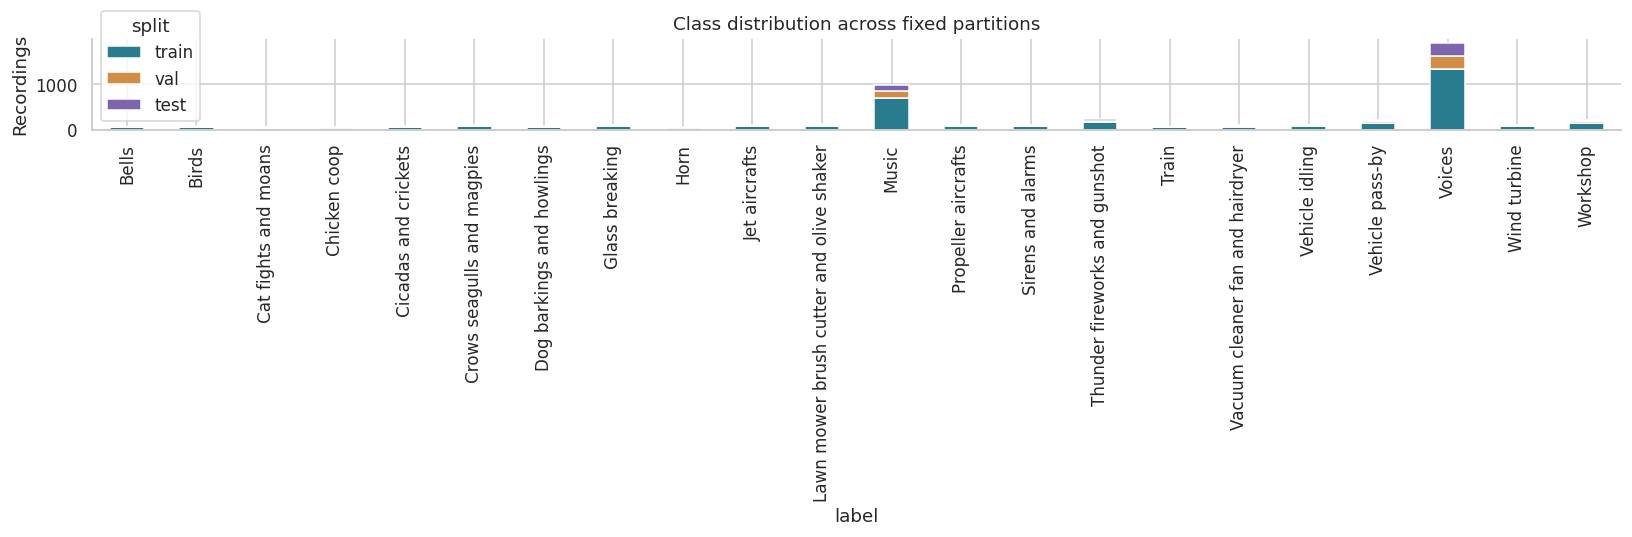

In [10]:
if GROUP_CSV:
    groups = pd.read_csv(GROUP_CSV, dtype=str)
    assert {"relative_path", "group_id"} <= set(groups.columns)
    assert not groups.relative_path.duplicated().any()
    df = df.merge(groups[["relative_path", "group_id"]], on="relative_path", how="left", validate="one_to_one")
    assert df.group_id.notna().all(), "Missing source groups."
else:
    df["group_id"] = df.audio_hash
if SHARED_SPLIT:
    shared = pd.read_csv(SHARED_SPLIT, dtype={"group_id": str})
    assert not shared.relative_path.duplicated().any()
    assert set(shared.relative_path) == set(df.relative_path), "Manifest and cleaned dataset differ."
    check = df.merge(shared[["relative_path", "label", "split"]], on="relative_path", suffixes=("", "_saved"), validate="one_to_one")
    assert (check.label == check.label_saved).all(), "Manifest labels differ."
    df = check.drop(columns="label_saved")
    if "group_id" in shared and not GROUP_CSV:
        df["group_id"] = df.relative_path.map(shared.set_index("relative_path").group_id)
elif GROUP_CSV:
    splitter = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
    df["fold"] = -1
    for fold, (_, idx) in enumerate(splitter.split(df, df.label, df.group_id)):
        df.loc[idx, "fold"] = fold
    df["split"] = np.where(df.fold < 2, "test", np.where(df.fold == 2, "val", "train"))
else:
    train_idx, rest_idx = train_test_split(df.index, test_size=.30, stratify=df.label, random_state=SEED)
    val_idx, test_idx = train_test_split(rest_idx, test_size=.50, stratify=df.loc[rest_idx, "label"], random_state=SEED)
    df["split"] = "train"
    df.loc[val_idx, "split"] = "val"
    df.loc[test_idx, "split"] = "test"
assert set(df.split) == {"train", "val", "test"}
assert df.group_id.notna().all()
assert df.groupby("group_id").split.nunique().max() == 1, "Source group leakage"
assert df.groupby("audio_hash").split.nunique().max() == 1, "Duplicate leakage"
class_names = sorted(df.label.unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}
df["target"] = df.label.map(class_to_idx)
for split in ["train", "val", "test"]:
    assert set(df.loc[df.split == split, "label"]) == set(class_names), f"Missing classes in {split}; revise grouping/split."
manifest_cols = ["relative_path", "label", "target", "split", "group_id", "audio_hash", "duration"]
df[manifest_cols].sort_values("relative_path").to_csv(OUTPUT / "split_manifest.csv", index=False)
(OUTPUT / "class_mapping.json").write_text(json.dumps(class_to_idx, indent=2))
partitions = {s: df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"]}
split_counts = pd.crosstab(df.label, df.split).reindex(columns=["train", "val", "test"])
display(split_counts)
split_counts.plot.bar(stacked=True, figsize=(15,5), color=["#287c8e", "#d28c45", "#7c65ad"])
plt.ylabel("Recordings"); plt.title("Class distribution across fixed partitions"); plt.tight_layout(); plt.show()


## 6. Waveforms, spectra and listening examples
Audio is converted to mono and resampled using a polyphase low-pass resampler. The charts below show a maximum of six seconds from six training recordings. Spectrograms are only for EDA; the classifier receives raw waveforms. Listen to the examples to assess background noise, event duration and whether short crops are representative.


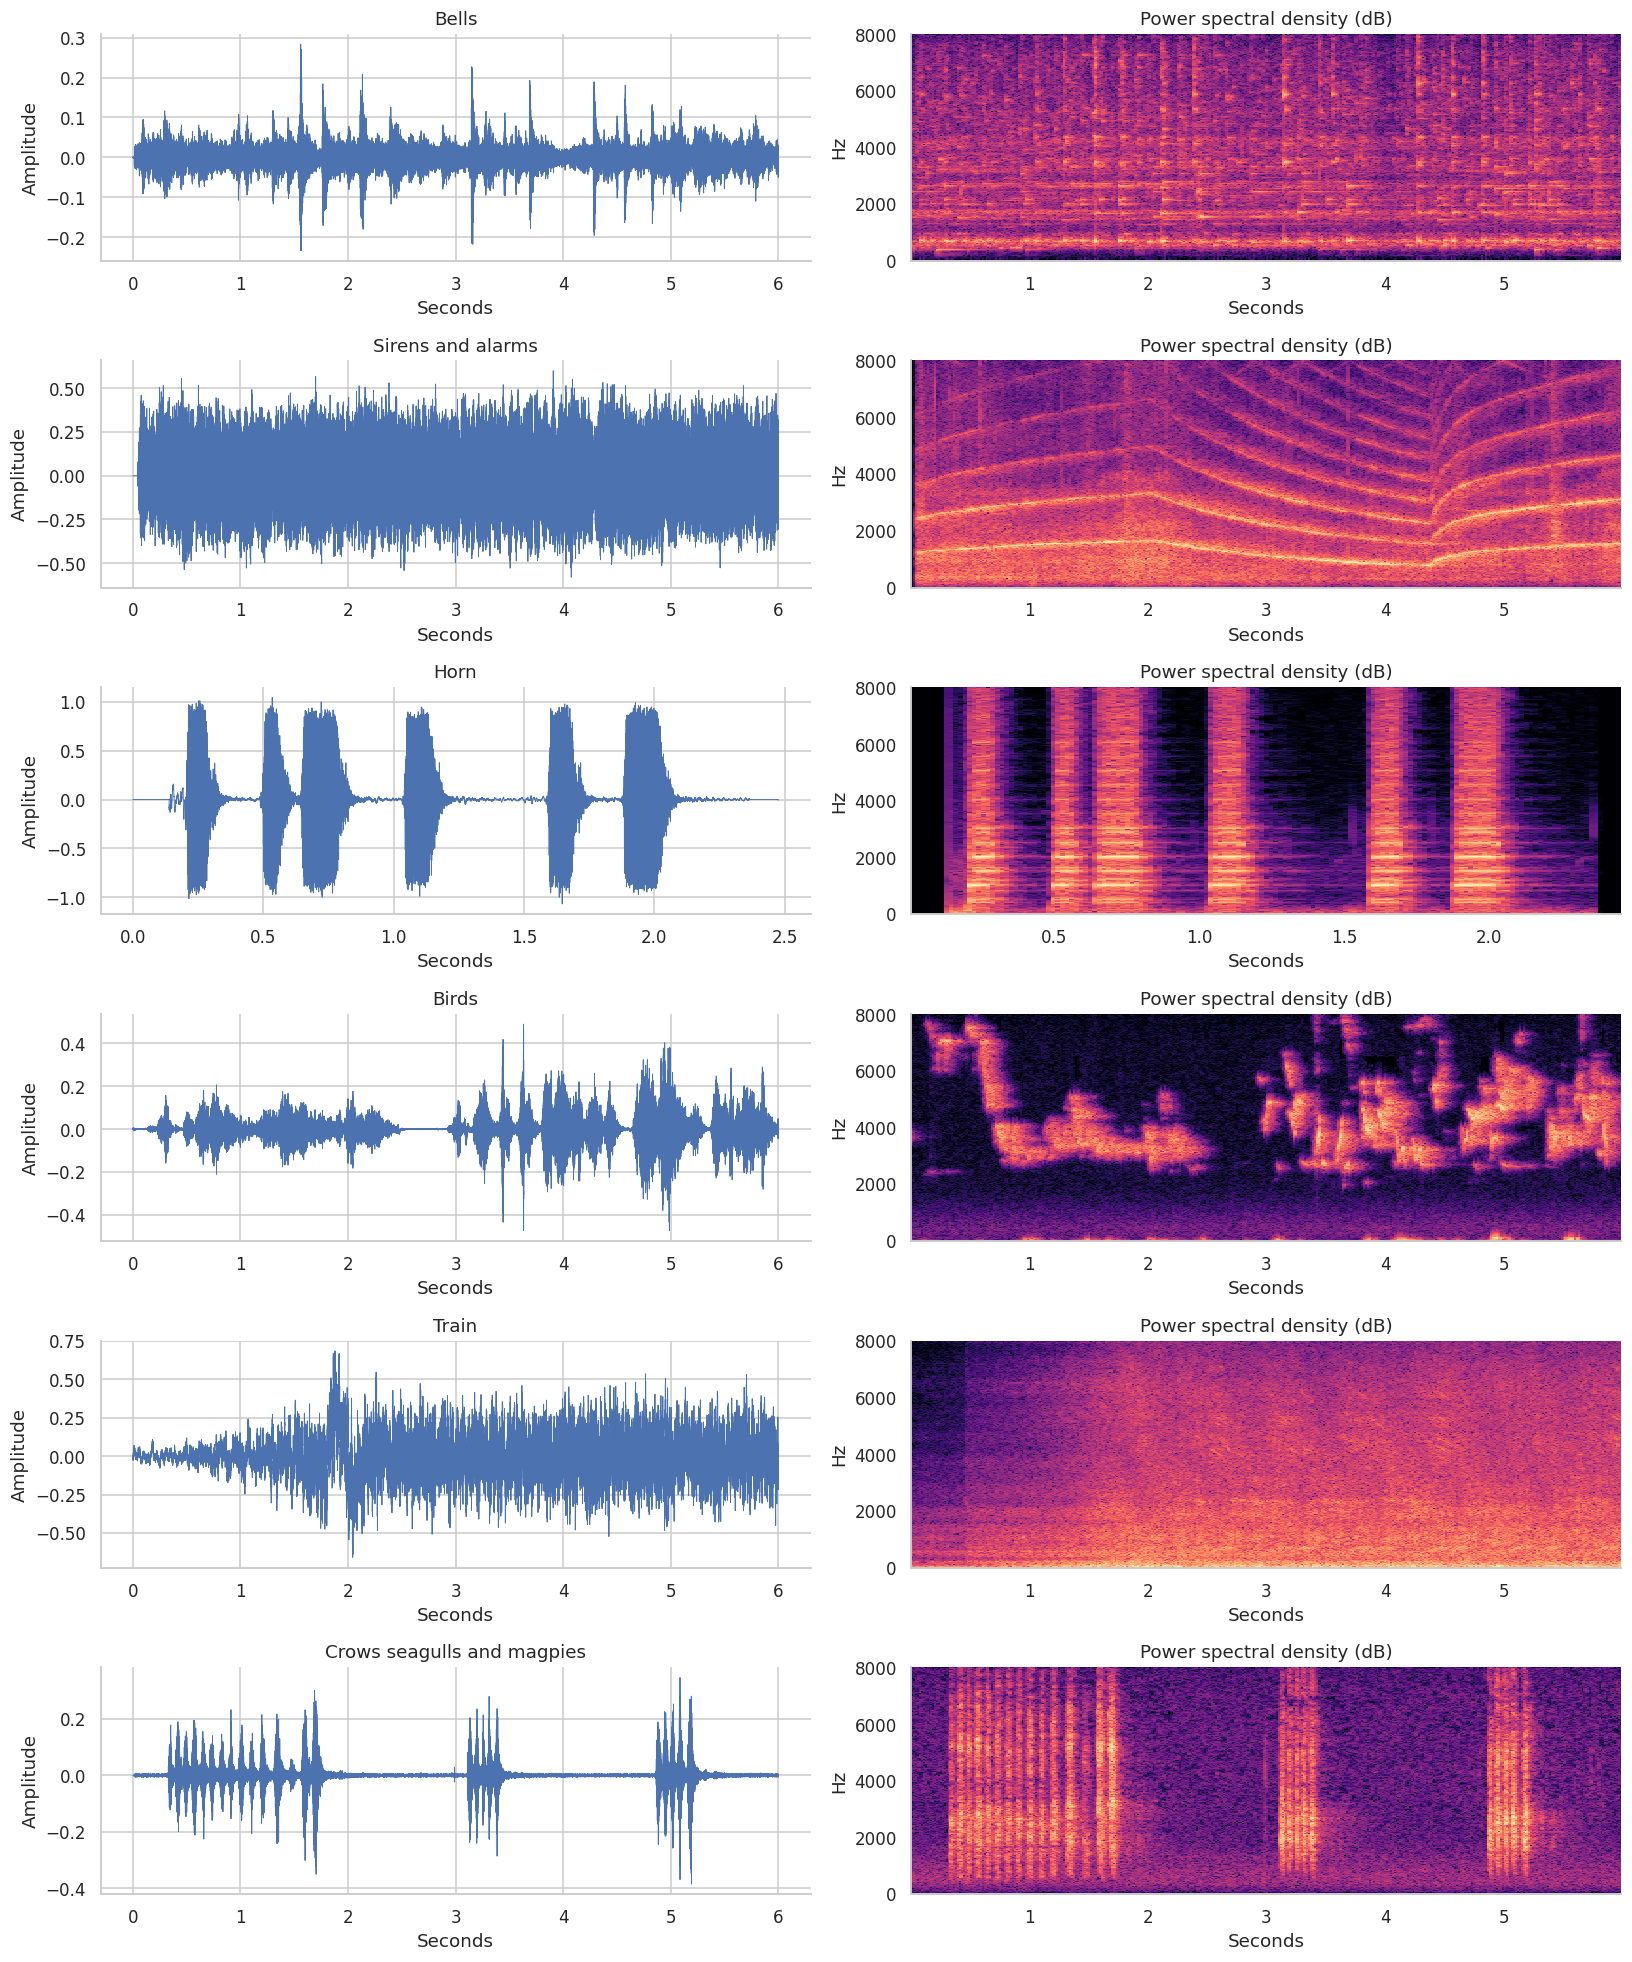

**Bells**

**Sirens and alarms**

**Horn**

In [11]:
def load_audio(path):
    x, sr = sf.read(path, dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    if sr != SAMPLE_RATE:
        g = math.gcd(sr, SAMPLE_RATE)
        x = resample_poly(x, SAMPLE_RATE//g, sr//g).astype(np.float32)
    return np.ascontiguousarray(x, dtype=np.float32)
examples = partitions["train"].groupby("label", group_keys=False).sample(n=1, random_state=SEED).sample(n=min(6, len(class_names)), random_state=SEED)
fig, axes = plt.subplots(len(examples), 2, figsize=(15, 3*len(examples)), squeeze=False)
for i, row in enumerate(examples.itertuples()):
    x = load_audio(row.path)[:6*SAMPLE_RATE]
    axes[i,0].plot(np.arange(len(x))/SAMPLE_RATE, x, lw=.6)
    axes[i,0].set(title=row.label, xlabel="Seconds", ylabel="Amplitude")
    nseg = min(512, len(x))
    f, t, power = spectrogram(x, fs=SAMPLE_RATE, nperseg=nseg, noverlap=nseg//2)
    axes[i,1].pcolormesh(t, f, 10*np.log10(power+1e-12), shading="auto", cmap="magma")
    axes[i,1].set(xlabel="Seconds", ylabel="Hz", title="Power spectral density (dB)")
plt.tight_layout(); plt.savefig(OUTPUT / "training_signal_examples.png", bbox_inches="tight"); plt.show()
for row in list(examples.itertuples())[:3]:
    display(Markdown(f"**{row.label}**"))
    display(Audio(load_audio(row.path)[:6*SAMPLE_RATE], rate=SAMPLE_RATE))


## 7. Cache and crop pipeline
Resampled mono recordings are cached once as float32 arrays. Disk-backed reads avoid loading the entire dataset into RAM, and the cache key includes the decoded-audio hash and sample rate. Disk requirements are estimated before caching.

Each crop is mean-centered and normalized by its own peak, with zero padding for short files. This uses no dataset-wide statistics. A mild random gain is applied only during training. Evaluation uses identical deterministic crop positions on every run. No crops are created before splitting.


In [12]:
CACHE = OUTPUT / f"cache_{SAMPLE_RATE}"
CACHE.mkdir(exist_ok=True)
needed = int(df.duration.sum()*SAMPLE_RATE*4)
print(f"Estimated cache size: {needed/1024**3:.2f} GiB")
assert shutil.disk_usage(OUTPUT).free > needed + 512*1024**2, "Insufficient disk space for audio cache."
def cache_audio(row):
    p = CACHE / f"{row.audio_hash}.npy"
    if not p.exists():
        np.save(p, load_audio(row.path), allow_pickle=False)
    return str(p)
df["cache_path"] = [cache_audio(row) for row in tqdm(df.itertuples(), total=len(df), desc="Caching audio")]
partitions = {s: df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"]}
def prepare_crop(x, start, length=N_SAMPLES):
    crop = np.array(x[start:start+length], dtype=np.float32, copy=True)
    crop -= crop.mean() if len(crop) else 0
    crop /= max(float(np.abs(crop).max()) if len(crop) else 0, 1e-6)
    return np.pad(crop, (0, max(0, length-len(crop))))
class AudioDataset(Dataset):
    def __init__(self, frame, training=False):
        self.rows = frame.to_dict("records")
        self.training = training
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        row = self.rows[idx]
        x = np.load(row["cache_path"], mmap_mode="r")
        last = max(0, len(x)-N_SAMPLES)
        if self.training:
            starts = [np.random.randint(last+1)]
        else:
            starts = np.linspace(0, last, EVAL_CROPS).round().astype(int)
        crops = np.stack([prepare_crop(x, int(s)) for s in starts])
        if self.training:
            crops *= np.random.uniform(.8, 1.2)
        return torch.from_numpy(crops), int(row["target"])
def seed_worker(worker_id):
    seed = torch.initial_seed() % 2**32
    np.random.seed(seed); random.seed(seed)
generator = torch.Generator().manual_seed(SEED)
loaders = {s: DataLoader(AudioDataset(frame, s == "train"), batch_size=BATCH_SIZE,
             shuffle=s == "train", num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
             worker_init_fn=seed_worker, generator=generator if s == "train" else None)
           for s, frame in partitions.items()}
xb, yb = next(iter(loaders["train"]))
print("Training batch:", tuple(xb.shape), "Targets:", tuple(yb.shape))


Estimated cache size: 5.06 GiB


Caching audio:   0%|          | 0/5032 [00:00<?, ?it/s]

Training batch: (16, 1, 32000) Targets: (16,)


## 8. SincNet-based waveform model
A conventional convolution learns every filter coefficient independently. The first layer here learns only a lower and an upper cutoff for each band-pass filter:

$$h[n]=2f_h\,\mathrm{sinc}(2f_hn)-2f_l\,\mathrm{sinc}(2f_ln).$$

In this expression the frequencies are normalized by the sample rate, and sinc is $\sin(\pi x)/(\pi x)$. A Hamming window limits the finite filter's edge effects. Cutoffs start on a Mel-spaced grid and use a bounded parameterization that keeps $0<f_l<f_h<f_s/2$ throughout training.

The 80 learned sinc filters feed three temporal convolution blocks. Global mean and standard-deviation pooling summarize temporal features before the classifier. Stride, normalization, pooling and the head are practical adaptations for this environmental sound task. Training from scratch does not guarantee that this model will outperform pretrained alternatives.


In [13]:
class SincConv1d(nn.Module):
    def __init__(self, channels=80, kernel_size=251, sample_rate=16000, stride=8):
        super().__init__()
        assert kernel_size % 2 == 1
        self.sample_rate, self.stride = sample_rate, stride
        self.min_low, self.min_band = 20.0, 30.0
        self.ceiling = sample_rate/2 - 1.0
        mel = lambda hz: 2595*np.log10(1+hz/700)
        hz = lambda m: 700*(10**(m/2595)-1)
        edges = hz(np.linspace(mel(50), mel(self.ceiling-100), channels+1))
        low = edges[:-1]
        high = np.maximum(edges[1:], low+self.min_band+1)
        high = np.minimum(high, self.ceiling-1)
        low_ratio = (low-self.min_low)/(self.ceiling-self.min_low-self.min_band)
        band_ratio = (high-low-self.min_band)/(self.ceiling-low-self.min_band)
        logit = lambda a: np.log(np.clip(a, 1e-5, 1-1e-5)/(1-np.clip(a, 1e-5, 1-1e-5)))
        self.low_raw = nn.Parameter(torch.tensor(logit(low_ratio), dtype=torch.float32))
        self.band_raw = nn.Parameter(torch.tensor(logit(band_ratio), dtype=torch.float32))
        self.register_buffer("time_axis", torch.arange(-(kernel_size//2), kernel_size//2+1).float()/sample_rate)
        self.register_buffer("window", torch.hamming_window(kernel_size, periodic=False))
    def cutoffs(self):
        low = self.min_low + (self.ceiling-self.min_low-self.min_band)*self.low_raw.sigmoid()
        high = low+self.min_band+(self.ceiling-low-self.min_band)*self.band_raw.sigmoid()
        return low, high
    def filters(self):
        low, high = self.cutoffs()
        t = self.time_axis[None,:]
        h = 2*high[:,None]*torch.sinc(2*high[:,None]*t)-2*low[:,None]*torch.sinc(2*low[:,None]*t)
        h = h*self.window[None,:]/(2*(high-low)[:,None])
        return h[:,None,:]
    def forward(self, x):
        return F.conv1d(x, self.filters(), stride=self.stride, padding=self.time_axis.numel()//2)
class SincNetClassifier(nn.Module):
    def __init__(self, n_classes, sample_rate=SAMPLE_RATE):
        super().__init__()
        self.sinc = SincConv1d(sample_rate=sample_rate)
        self.front = nn.Sequential(nn.BatchNorm1d(80), nn.LeakyReLU(.1), nn.MaxPool1d(4))
        blocks=[]
        for cin, cout in [(80,128),(128,128),(128,256)]:
            blocks.extend([nn.Conv1d(cin,cout,5,padding=2,bias=False), nn.BatchNorm1d(cout),
                           nn.LeakyReLU(.1), nn.MaxPool1d(4), nn.Dropout(.15)])
        self.encoder=nn.Sequential(*blocks)
        self.head=nn.Sequential(nn.Linear(512,128), nn.LeakyReLU(.1), nn.Dropout(.35), nn.Linear(128,n_classes))
    def forward(self,x):
        x=self.encoder(self.front(self.sinc(x)))
        x=torch.cat([x.mean(-1), x.std(-1,unbiased=False)],dim=1)
        return self.head(x)
model = SincNetClassifier(len(class_names)).to(DEVICE)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
initial_filters = model.sinc.filters().detach().cpu().numpy()[:,0]
with torch.no_grad():
    test_logits = model(xb.to(DEVICE))
assert test_logits.shape == (len(xb),len(class_names)) and torch.isfinite(test_logits).all()
print(model)
print(f"Trainable parameters: {parameter_count:,}")


SincNetClassifier(
  (sinc): SincConv1d()
  (front): Sequential(
    (0): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (encoder): Sequential(
    (0): Conv1d(80, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.15, inplace=False)
    (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.1)
    (8): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.15, inplace=False)
    (10): Conv1d(128, 2

## 9. Training and validation
Inverse-frequency class weights are computed from training labels only. Weighted cross-entropy addresses class imbalance, while validation macro-F1 gives every class equal importance. AdamW, gradient clipping, a validation-based learning-rate scheduler and early stopping stabilize training.

Validation loss is unweighted recording-level negative log likelihood after averaging crop probabilities. It is intentionally different from weighted training crop loss. Compare the curves as optimization diagnostics, not identical objectives. Float32 is used throughout for a straightforward sinc implementation. Reduce `BATCH_SIZE` to 8 if GPU memory is limited.


In [14]:
train_counts = np.bincount(partitions["train"].target, minlength=len(class_names))
weights = len(partitions["train"])/(len(class_names)*train_counts)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights,dtype=torch.float32,device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=.5,patience=3)
config = {"seed":SEED,"sample_rate":SAMPLE_RATE,"crop_seconds":CROP_SECONDS,"eval_crops":EVAL_CROPS,
          "batch_size":BATCH_SIZE,"epochs":EPOCHS,"learning_rate":LEARNING_RATE,"weight_decay":WEIGHT_DECAY,
          "class_names":class_names,"parameters":parameter_count,"torch_version":str(torch.__version__),
          "split_sha256":hashlib.sha256((OUTPUT/"split_manifest.csv").read_bytes()).hexdigest()}
(OUTPUT/"config.json").write_text(json.dumps(config,indent=2))
def metrics(y,pred):
    p,r,f,_=precision_recall_fscore_support(y,pred,labels=np.arange(len(class_names)),average="macro",zero_division=0)
    return {"accuracy":float(accuracy_score(y,pred)),"macro_precision":float(p),"macro_recall":float(r),"macro_f1":float(f)}
@torch.no_grad()
def evaluate(loader):
    model.eval()
    targets, probabilities=[],[]
    for x,y in loader:
        b,k,n=x.shape
        flat=x.reshape(b*k,1,n)
        chunks=[]
        for chunk in flat.split(BATCH_SIZE):
            chunks.append(model(chunk.to(DEVICE,non_blocking=True)).softmax(-1).cpu())
        prob=torch.cat(chunks).reshape(b,k,-1).mean(1)
        probabilities.append(prob.numpy()); targets.append(y.numpy())
    y=np.concatenate(targets); prob=np.concatenate(probabilities)
    loss=float(-np.log(np.clip(prob[np.arange(len(y)),y],1e-12,1)).mean())
    return loss,metrics(y,prob.argmax(1)),y,prob
history=[]
best_f1=-1.0
stale=0
start_training=time.perf_counter()
if DEVICE.type=="cuda": torch.cuda.reset_peak_memory_stats()
for epoch in range(1,EPOCHS+1):
    model.train()
    numerator,denominator,correct,total=0.0,0.0,0,0
    epoch_start=time.perf_counter()
    for x,y in tqdm(loaders["train"],desc=f"Epoch {epoch}/{EPOCHS}",leave=False):
        x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits=model(x)
        loss=criterion(logits,y)
        if not torch.isfinite(loss): raise RuntimeError("Nonfinite loss")
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),5.0)
        optimizer.step()
        batch_weight=criterion.weight[y].sum().item()
        numerator+=loss.item()*batch_weight; denominator+=batch_weight
        correct+=(logits.argmax(1)==y).sum().item(); total+=len(y)
    val_loss,val_metrics,_,_=evaluate(loaders["val"])
    scheduler.step(val_metrics["macro_f1"])
    row={"epoch":epoch,"train_loss":numerator/denominator,"train_accuracy":correct/total,
         "val_loss":val_loss,**{f"val_{k}":v for k,v in val_metrics.items()},
         "lr":optimizer.param_groups[0]["lr"],"seconds":time.perf_counter()-epoch_start}
    history.append(row)
    pd.DataFrame(history).to_csv(OUTPUT/"history.csv",index=False)
    print(f"Epoch {epoch:02d} | loss {row['train_loss']:.4f} | val accuracy {val_metrics['accuracy']:.4f} | val macro-F1 {val_metrics['macro_f1']:.4f}")
    if val_metrics["macro_f1"]>best_f1+1e-5:
        best_f1=val_metrics["macro_f1"]; stale=0
        torch.save({"model_state":model.state_dict(),"config":config,"epoch":epoch,"val_macro_f1":best_f1},OUTPUT/"best_model.pt")
    else:
        stale+=1
    if stale>=PATIENCE:
        print("Early stopping."); break
training_seconds=time.perf_counter()-start_training
peak_gpu_mb=torch.cuda.max_memory_allocated()/1024**2 if DEVICE.type=="cuda" else None
checkpoint=torch.load(OUTPUT/"best_model.pt",map_location=DEVICE,weights_only=True)
model.load_state_dict(checkpoint["model_state"])
print("Restored best epoch:",checkpoint["epoch"])


Epoch 1/40:   0%|          | 0/221 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fc4d6034b80>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fc4d6034b80>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    self._shutdown_workers()if w.is_alive():

    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
     ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

Epoch 01 | loss 2.4682 | val accuracy 0.4993 | val macro-F1 0.3005


Epoch 2/40:   0%|          | 0/221 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fc4d6034b80>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fc4d6034b80>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()        self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():
    if w.is_alive(): 
           ^ ^ ^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

...

Epoch 34/40:   0%|          | 0/221 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fc4d6034b80>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fc4d6034b80>
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

     if w.is_alive(): 
         ^ ^  ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'
 ^ 
   File "/usr/lib/pyt

Epoch 34 | loss 0.6280 | val accuracy 0.8371 | val macro-F1 0.6949


Epoch 35/40:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 35 | loss 0.6078 | val accuracy 0.8530 | val macro-F1 0.7222
Early stopping.
Restored best epoch: 27


## 10. Learning curves and final held-out evaluation
The checkpoint was selected without consulting test scores. Accuracy measures overall correctness, while macro precision, recall and F1 give equal weight to each parent class. The row-normalized confusion matrix measures recall patterns: each row sums to one. The majority-class baseline predicts the most frequent training label for every test recording.

Inference time below includes cached data loading and all evaluation crops. It is an end-to-end measurement for this session, not a hardware-independent latency benchmark.


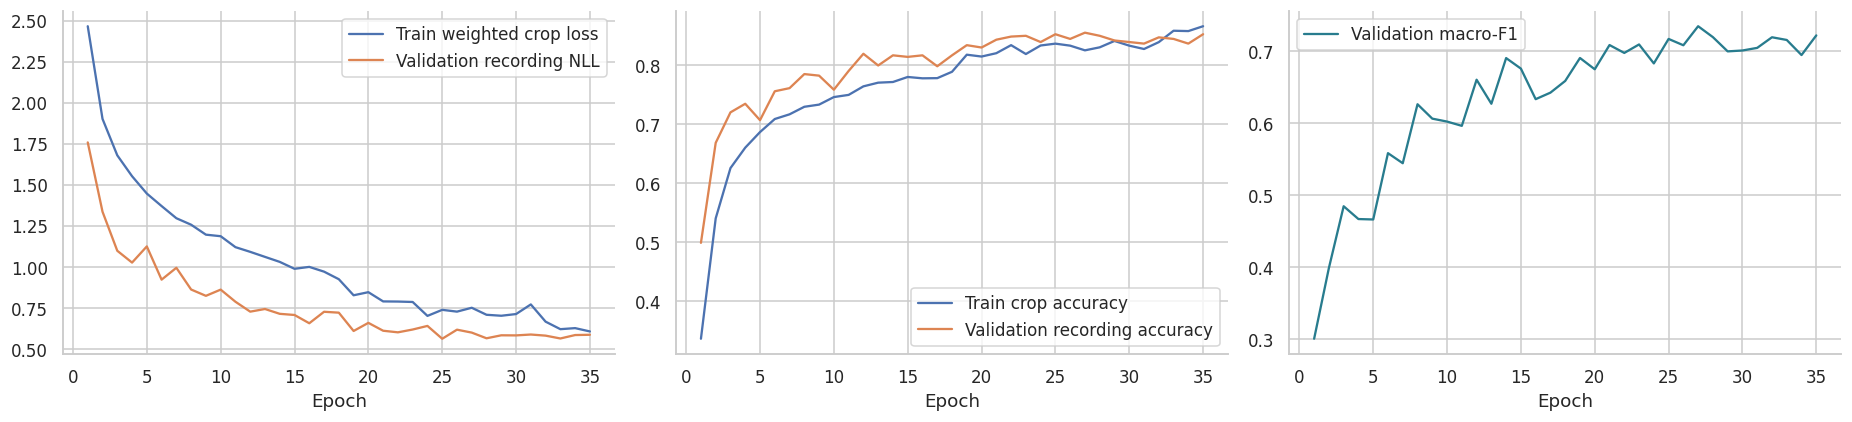

,accuracy,macro_precision,macro_recall,macro_f1
Training majority baseline,0.377483,0.017158,0.045455,0.024913
SincNet,0.864901,0.755577,0.766293,0.740161


,precision,recall,f1-score,support
Bells,0.8000,0.8000,0.8000,10.0000
Birds,0.7692,1.0000,0.8696,10.0000
Cat fights and moans,1.0000,0.5714,0.7273,7.0000
Chicken coop,0.8750,0.7778,0.8235,9.0000
Cicadas and crickets,0.5556,0.9091,0.6897,11.0000
Crows seagulls and magpies,1.0000,0.7500,0.8571,16.0000
Dog barkings and howlings,0.5263,0.9091,0.6667,11.0000
Glass breaking,1.0000,0.9375,0.9677,16.0000
Horn,0.8750,0.7778,0.8235,9.0000
Jet aircrafts,0.5000,0.7500,0.6000,16.0000


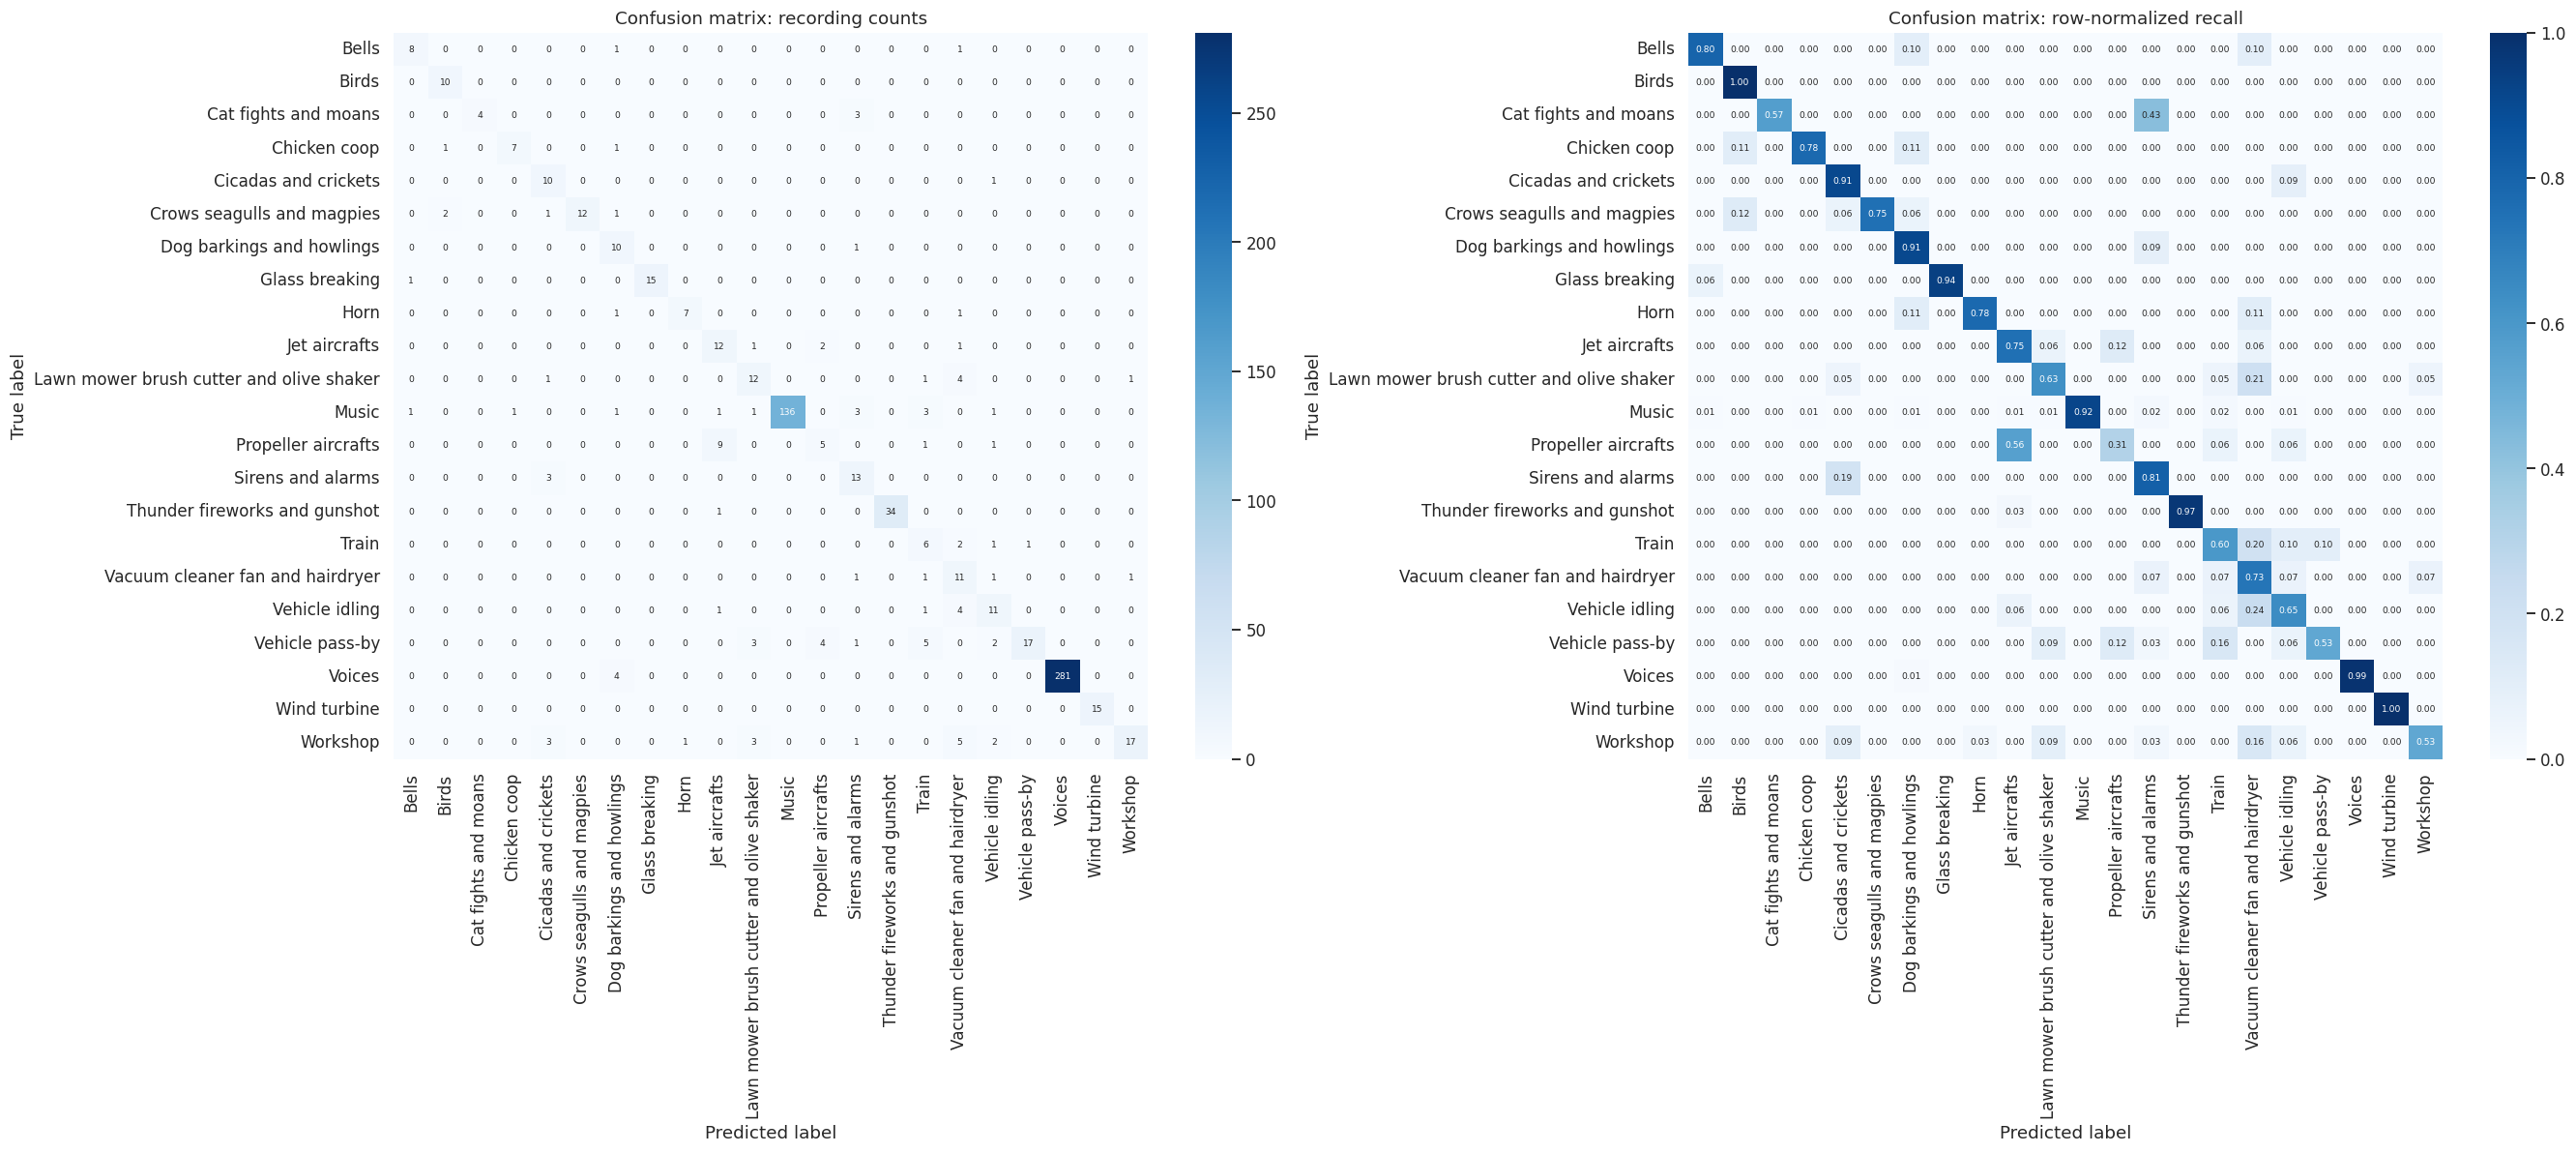

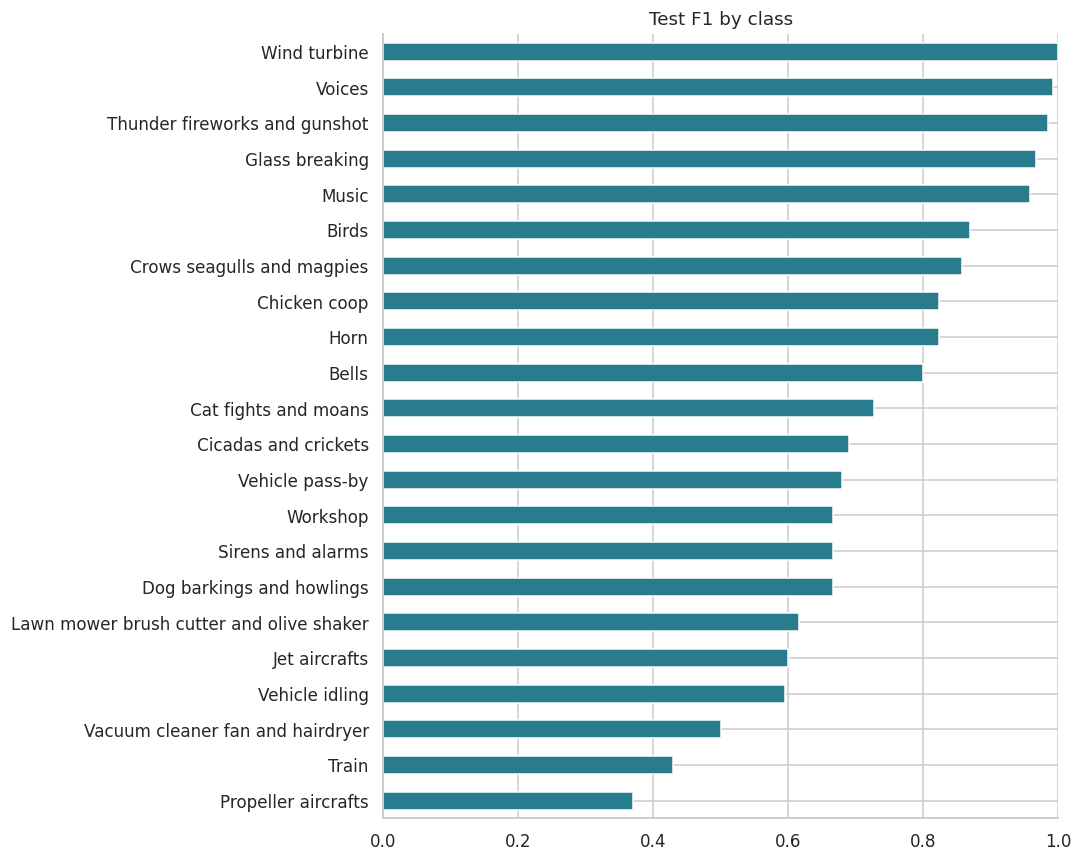

In [15]:
hist=pd.DataFrame(history)
fig,axes=plt.subplots(1,3,figsize=(17,4))
axes[0].plot(hist.epoch,hist.train_loss,label="Train weighted crop loss")
axes[0].plot(hist.epoch,hist.val_loss,label="Validation recording NLL")
axes[1].plot(hist.epoch,hist.train_accuracy,label="Train crop accuracy")
axes[1].plot(hist.epoch,hist.val_accuracy,label="Validation recording accuracy")
axes[2].plot(hist.epoch,hist.val_macro_f1,label="Validation macro-F1",color="#287c8e")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.legend()
plt.tight_layout(); plt.savefig(OUTPUT/"learning_curves.png",bbox_inches="tight"); plt.show()
if DEVICE.type=="cuda": torch.cuda.synchronize()
t0=time.perf_counter()
test_loss,test_metrics,y_true,probabilities=evaluate(loaders["test"])
if DEVICE.type=="cuda": torch.cuda.synchronize()
inference_seconds=time.perf_counter()-t0
y_pred=probabilities.argmax(1)
majority=int(np.argmax(train_counts))
baseline=metrics(y_true,np.full_like(y_true,majority))
display(pd.DataFrame([baseline,test_metrics],index=["Training majority baseline","SincNet"]))
report=pd.DataFrame(classification_report(y_true,y_pred,labels=np.arange(len(class_names)),target_names=class_names,output_dict=True,zero_division=0)).T
report.to_csv(OUTPUT/"classification_report.csv")
display(report.round(4))
results={**test_metrics,"test_loss":test_loss,"best_epoch":checkpoint["epoch"],"best_val_macro_f1":best_f1,
         "training_seconds":training_seconds,"test_inference_seconds":inference_seconds,
         "test_recordings_per_second":len(y_true)/inference_seconds,"peak_gpu_allocated_mb":peak_gpu_mb,
         "parameters":parameter_count,"train_recordings":len(partitions["train"]),"test_recordings":len(y_true),
         "device":torch.cuda.get_device_name() if DEVICE.type=="cuda" else "CPU","baseline":baseline}
(OUTPUT/"metrics.json").write_text(json.dumps(results,indent=2))
cm=confusion_matrix(y_true,y_pred,labels=np.arange(len(class_names)))
cm_normalized=cm/np.maximum(cm.sum(1,keepdims=True),1)
fig,axes=plt.subplots(1,2,figsize=(25,11))
for ax,data,title,fmt in [(axes[0],cm,"Confusion matrix: recording counts","d"),(axes[1],cm_normalized,"Confusion matrix: row-normalized recall",".2f")]:
    sns.heatmap(data,ax=ax,cmap="Blues",xticklabels=class_names,yticklabels=class_names,annot=True,fmt=fmt,annot_kws={"size":6})
    ax.set(title=title,xlabel="Predicted label",ylabel="True label")
plt.tight_layout(); plt.savefig(OUTPUT/"confusion_matrices.png",bbox_inches="tight"); plt.show()
pd.DataFrame(cm,index=class_names,columns=class_names).to_csv(OUTPUT/"confusion_matrix.csv")
report.loc[class_names,"f1-score"].sort_values().plot.barh(figsize=(10,8),color="#287c8e",xlim=(0,1),title="Test F1 by class")
plt.tight_layout(); plt.savefig(OUTPUT/"per_class_f1.png",bbox_inches="tight"); plt.show()


## 11. Error analysis and learned filters
The table lists confident mistakes for qualitative discussion. Confidence is the model's softmax score and is not a calibrated probability of correctness. Listening to errors can suggest follow-up hypotheses, but a new experiment must preserve a genuinely untouched evaluation set.

Learned frequency responses show how the first layer changes from its initialization. Each response is normalized to its own peak for readability, so the plots compare frequency selectivity rather than absolute gain. These filters are descriptive evidence, not proof that a specific class caused a filter to move.


,relative_path,label,predicted_label,confidence
299,Sirens and alarms/Alarms/Alarms-0006.wav,Sirens and alarms,Cicadas and crickets,1.000000
397,Vehicle pass-by/car pass-by/car pass-by-0017.wav,Vehicle pass-by,Sirens and alarms,0.997604
35,Chicken coop/Chicken coop-0057.wav,Chicken coop,Birds,0.997595
133,Lawn mower brush cutter and olive shaker/Olive...,Lawn mower brush cutter and olive shaker,Cicadas and crickets,0.960556
5,Bells/Bells-0040.wav,Bells,Vacuum cleaner fan and hairdryer,0.939748
93,Horn/Horn-0017.wav,Horn,Dog barkings and howlings,0.936543
298,Sirens and alarms/Alarms/Alarms-0001.wav,Sirens and alarms,Cicadas and crickets,0.911060
62,Crows seagulls and magpies/Seagulls/Seagulls-0...,Crows seagulls and magpies,Birds,0.833646
56,Crows seagulls and magpies/Magpies/Magpies-000...,Crows seagulls and magpies,Birds,0.818946
734,Workshop/grinder/grinder-0035.wav,Workshop,Vacuum cleaner fan and hairdryer,0.793634


**True:** Sirens and alarms | **Predicted:** Cicadas and crickets | **Score:** 1.000

**True:** Vehicle pass-by | **Predicted:** Sirens and alarms | **Score:** 0.998

**True:** Chicken coop | **Predicted:** Birds | **Score:** 0.998

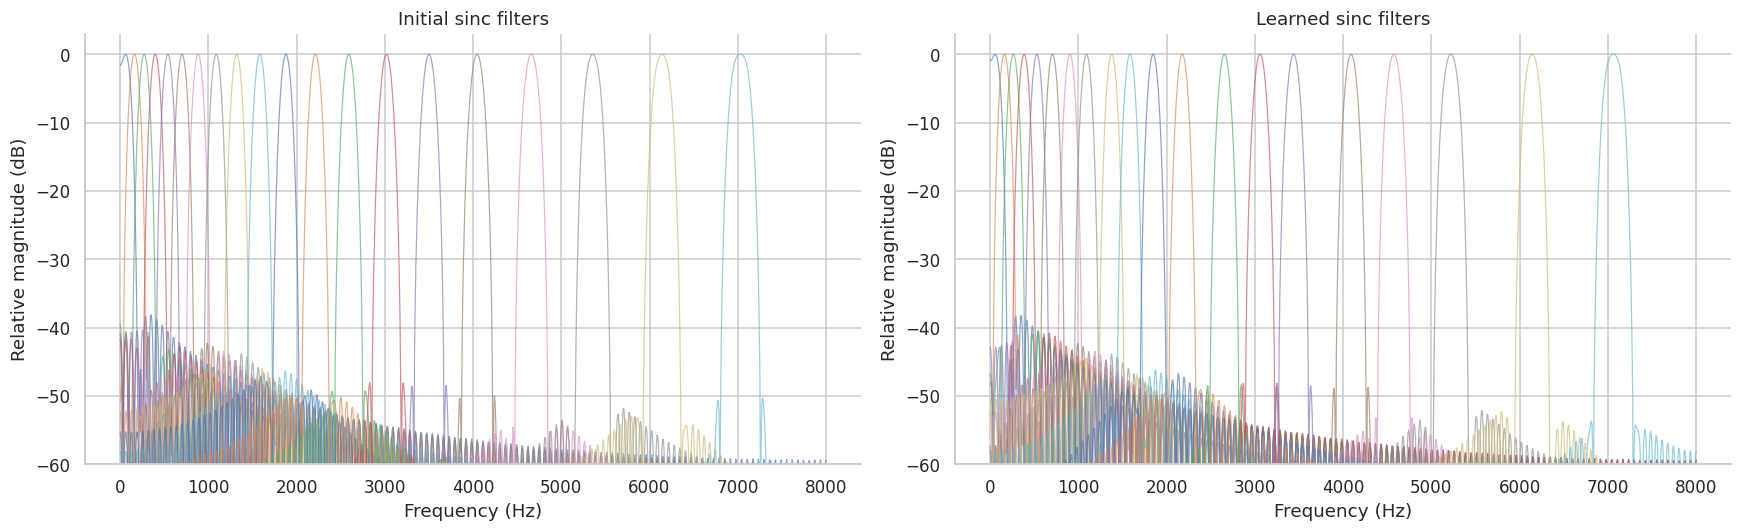

In [16]:
predictions=partitions["test"][["relative_path","label"]].copy()
predictions["predicted_label"]=[class_names[i] for i in y_pred]
predictions["confidence"]=probabilities.max(1)
predictions["correct"]=y_true==y_pred
for i,name in enumerate(class_names): predictions[f"p_{name}"]=probabilities[:,i]
predictions.to_csv(OUTPUT/"test_predictions.csv",index=False)
errors=predictions[~predictions.correct].sort_values("confidence",ascending=False)
display(errors[["relative_path","label","predicted_label","confidence"]].head(15))
for idx,row in errors.head(3).iterrows():
    display(Markdown(f"**True:** {row.label} | **Predicted:** {row.predicted_label} | **Score:** {row.confidence:.3f}"))
    display(Audio(load_audio(partitions["test"].iloc[idx].path)[:6*SAMPLE_RATE],rate=SAMPLE_RATE))
with torch.no_grad():
    learned=model.sinc.filters().cpu().numpy()[:,0]
    low,high=model.sinc.cutoffs()
cutoffs=pd.DataFrame({"filter":np.arange(len(low)),"low_hz":low.detach().cpu().numpy(),"high_hz":high.detach().cpu().numpy()})
cutoffs.to_csv(OUTPUT/"learned_cutoffs.csv",index=False)
fig,axes=plt.subplots(1,2,figsize=(16,5))
freq=np.fft.rfftfreq(2048,1/SAMPLE_RATE)
for ax,filters,title in [(axes[0],initial_filters,"Initial sinc filters"),(axes[1],learned,"Learned sinc filters")]:
    response=np.abs(np.fft.rfft(filters,n=2048,axis=1))
    response=20*np.log10(response/np.maximum(response.max(1,keepdims=True),1e-12)+1e-8)
    for curve in response[::4]: ax.plot(freq,curve,alpha=.65,lw=.8)
    ax.set(title=title,xlabel="Frequency (Hz)",ylabel="Relative magnitude (dB)",ylim=(-60,3))
plt.tight_layout(); plt.savefig(OUTPUT/"sinc_filter_responses.png",bbox_inches="tight"); plt.show()


## 12. Predict a new WAV recording
`predict_file` uses the same mono conversion, resampling, crop normalization and probability averaging as test evaluation. The output is restricted to the 22 trained classes. An unrelated or mixed sound still receives one of these labels, so this is not an unknown-event detector.

To reload in another session, run the imports and model definitions, read `config.json`, restore its sample rate, crop length and evaluation crop count, instantiate `SincNetClassifier` with the saved class count, and load `best_model.pt`. Keep the class order from the checkpoint.


In [17]:
@torch.no_grad()
def predict_file(path, top_k=5):
    model.eval()
    x=load_audio(path)
    assert len(x)>0 and np.isfinite(x).all(), "Invalid audio"
    starts=np.linspace(0,max(0,len(x)-N_SAMPLES),EVAL_CROPS).round().astype(int)
    crops=torch.from_numpy(np.stack([prepare_crop(x,int(s)) for s in starts]))[:,None,:]
    probs=torch.cat([model(c.to(DEVICE)).softmax(1).cpu() for c in crops.split(BATCH_SIZE)]).mean(0).numpy()
    idx=np.argsort(probs)[::-1][:min(top_k,len(class_names))]
    return pd.DataFrame({"class":[class_names[i] for i in idx],"score":probs[idx]})
example_path=partitions["test"].iloc[0].path
print("Example:",example_path)
display(predict_file(example_path))


Example: /kaggle/working/sincnet_datasec/extracted/DATASEC/Bells/Bells-0002.wav


,class,score
0,Dog barkings and howlings,0.468632
1,Bells,0.381482
2,Chicken coop,0.062403
3,Sirens and alarms,0.053088
4,Music,0.019137


## 13. Results for the project report
Use the generated values rather than claiming an expected accuracy. Report the actual dataset release, exclusions, split counts, source-group availability, sample rate, crop policy and best epoch. Compare architectures using the same recording-level labels and partitions. State whether other models use pretraining, since this changes the interpretation of the comparison.

Limitations include potential source overlap without provenance groups, exact-hash detection missing near-duplicates, loss of high-frequency content at 16 kHz, sampled coverage of long events, and variation across random seeds. One run supports a baseline comparison, not a strong claim of statistical superiority. Further experiments should be chosen on validation evidence.

The export bundle contains the checkpoint, metrics, prediction probabilities, split manifest, class mapping, history, audit tables and figures. The large waveform cache and extracted dataset are excluded.


In [18]:
display(Markdown(f"""### Measured outcome
- Best epoch: **{checkpoint['epoch']}**
- Test accuracy: **{test_metrics['accuracy']:.4f}**
- Test macro precision: **{test_metrics['macro_precision']:.4f}**
- Test macro recall: **{test_metrics['macro_recall']:.4f}**
- Test macro F1: **{test_metrics['macro_f1']:.4f}**
- Training time: **{training_seconds/60:.1f} minutes**
- Trainable parameters: **{parameter_count:,}**
"""))
bundle=OUTPUT/"sincnet_results.zip"
with zipfile.ZipFile(bundle,"w",compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUTPUT.iterdir()):
        if p.is_file() and p!=bundle:
            z.write(p,p.name)
print("Saved:",bundle)
display(pd.DataFrame([{"file":p.name,"MiB":p.stat().st_size/1024**2} for p in OUTPUT.iterdir() if p.is_file()]))


### Measured outcome
- Best epoch: **27**
- Test accuracy: **0.8649**
- Test macro precision: **0.7556**
- Test macro recall: **0.7663**
- Test macro F1: **0.7402**
- Training time: **3.4 minutes**
- Trainable parameters: **366,806**


Saved: /kaggle/working/sincnet_datasec/sincnet_results.zip


,file,MiB
0,split_manifest.csv,0.957195
1,confusion_matrix.csv,0.001643
2,confusion_matrices.png,0.217724
3,test_predictions.csv,0.259650
4,training_signal_examples.png,1.682478
5,invalid_audio.csv,0.000113
6,sinc_filter_responses.png,0.271154
7,best_model.pt,1.417043
8,eda_overview.png,0.384848
9,metrics.json,0.000682


## References
1. Ravanelli, M. and Bengio, Y. [Speaker Recognition from Raw Waveform with SincNet](https://arxiv.org/abs/1808.00158), 2018. [Original implementation](https://github.com/mravanelli/SincNet).
2. Fredianelli, L. et al. [Environmental Noise Dataset for Sound Event Classification and Detection](https://www.nature.com/articles/s41597-025-05991-w), Scientific Data, 2025.
3. [DataSEC v3, DOI 10.5281/zenodo.17033970](https://zenodo.org/records/17033970). This release documents 4,292 recordings. [Older release cited in the synopsis](https://zenodo.org/records/15340689).

ChatGPT Codex assisted in generating this code.